# Relación entre B2B, dinero y cantidad

En este notebook queremos explorar la ....

In [1]:
from pathlib import Path
import pandas as pd

rutas_dataset = [
    Path('../data/Amazon_Sales.csv'),
    Path('data/Amazon_Sales.csv')
]
ruta_dataset = next((ruta for ruta in rutas_dataset if ruta.exists()), None)

if ruta_dataset is None:
    raise FileNotFoundError('No se encontro data/Amazon_Sales.csv')

df = pd.read_csv(ruta_dataset)

In [2]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B'],
      dtype='object')

Monedas disponibles: ['INR']

Resumen por tipo de cliente:
                 Amount                    Qty             
                  count    mean median   count  mean median
Tipo de cliente                                            
B2B                 871  678.78  653.0     871  0.96    1.0
No B2B           128104  608.89  582.0  128104  0.90    1.0


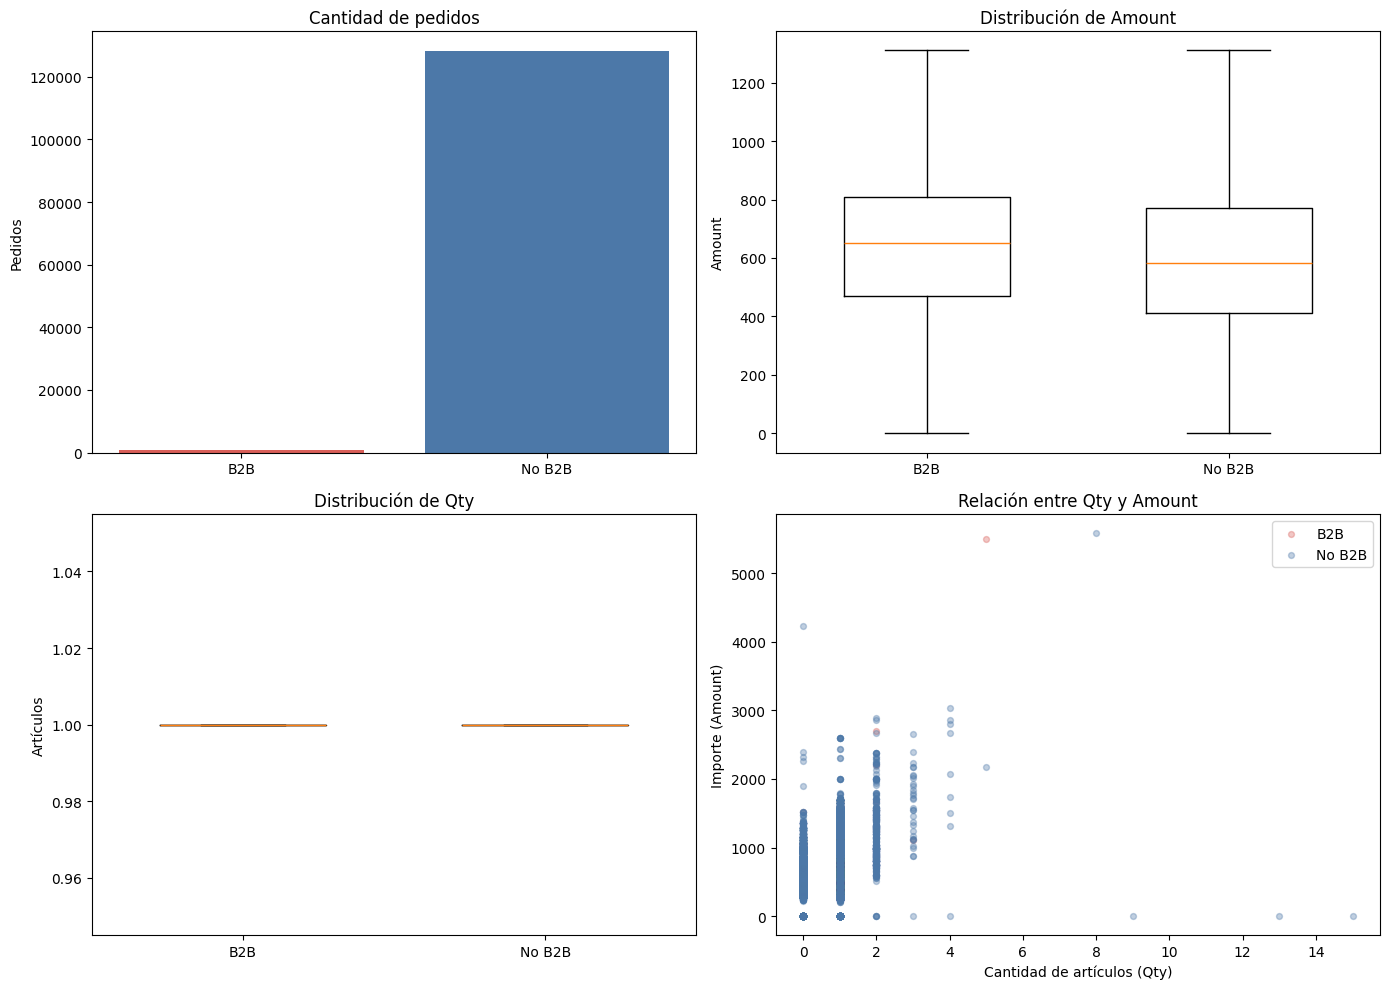


Correlación entre Qty y Amount por tipo de cliente:
                          Qty  Amount
Tipo de cliente                      
B2B             Qty     1.000   0.526
                Amount  0.526   1.000
No B2B          Qty     1.000   0.390
                Amount  0.390   1.000


In [3]:
import matplotlib.pyplot as plt

columnas = ['B2B', 'Amount', 'currency', 'Qty']
analisis = df[columnas].copy()
analisis['Amount'] = pd.to_numeric(analisis['Amount'], errors='coerce')
analisis['Qty'] = pd.to_numeric(analisis['Qty'], errors='coerce')
analisis['Tipo de cliente'] = analisis['B2B'].map({True: 'B2B', False: 'No B2B'})
analisis = analisis.dropna(subset=['Amount', 'Qty', 'Tipo de cliente'])

print('Monedas disponibles:', analisis['currency'].dropna().unique().tolist())
print('\nResumen por tipo de cliente:')
print(analisis.groupby('Tipo de cliente')[['Amount', 'Qty']].agg(['count', 'mean', 'median']).round(2))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Cantidad de pedidos por tipo de cliente.
conteo_b2b = analisis['Tipo de cliente'].value_counts().reindex(['B2B', 'No B2B'])
axes[0, 0].bar(conteo_b2b.index, conteo_b2b.values, color=['#D95F59', '#4C78A8'])
axes[0, 0].set_title('Cantidad de pedidos')
axes[0, 0].set_ylabel('Pedidos')

# Distribución del importe, separada por grupo B2B.
for posicion, grupo in enumerate(['B2B', 'No B2B']):
    valores = analisis.loc[analisis['Tipo de cliente'] == grupo, 'Amount']
    axes[0, 1].boxplot(valores, positions=[posicion], widths=0.55, showfliers=False)
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['B2B', 'No B2B'])
axes[0, 1].set_title('Distribución de Amount')
axes[0, 1].set_ylabel('Amount')

# Distribución de la cantidad de artículos por grupo.
for posicion, grupo in enumerate(['B2B', 'No B2B']):
    valores = analisis.loc[analisis['Tipo de cliente'] == grupo, 'Qty']
    axes[1, 0].boxplot(valores, positions=[posicion], widths=0.55, showfliers=False)
axes[1, 0].set_xticks([0, 1])
axes[1, 0].set_xticklabels(['B2B', 'No B2B'])
axes[1, 0].set_title('Distribución de Qty')
axes[1, 0].set_ylabel('Artículos')

# Relación entre cantidad de artículos e importe.
colores = {'B2B': '#D95F59', 'No B2B': '#4C78A8'}
for grupo, color in colores.items():
    datos_grupo = analisis[analisis['Tipo de cliente'] == grupo]
    axes[1, 1].scatter(datos_grupo['Qty'], datos_grupo['Amount'],
                       label=grupo, color=color, alpha=0.35, s=18)
axes[1, 1].set_title('Relación entre Qty y Amount')
axes[1, 1].set_xlabel('Cantidad de artículos (Qty)')
axes[1, 1].set_ylabel('Importe (Amount)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print('\nCorrelación entre Qty y Amount por tipo de cliente:')
print(analisis.groupby('Tipo de cliente')[['Qty', 'Amount']].corr().round(3))

<Axes: >

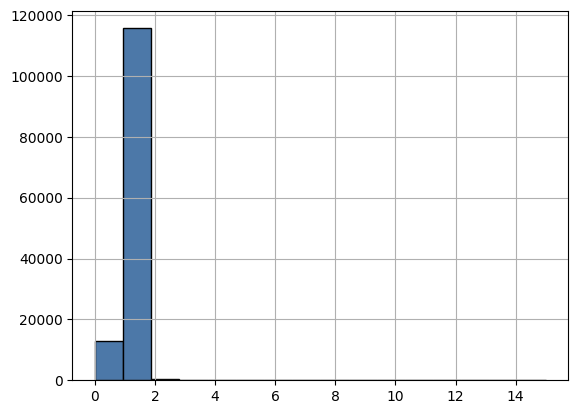

In [8]:
df["Qty"].hist(bins=16, color='#4C78A8', edgecolor='black')

In [ ]:
correlacion_b2b_amount = analisis['B2B'].astype(int).corr(analisis['Amount'])
print(f'Correlación entre B2B y Amount: {correlacion_b2b_amount:.3f}')